**IPL Win Probability Predictor**


 Import the libraries


In [64]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score
from sklearn.calibration import calibration_curve

Load the dataset

In [65]:
data = pd.read_csv("/content/chase_states.csv", dtype={"season": str})
print(data.shape, "|", data.isnull().sum().sum(), "nulls")

(138683, 14) | 0 nulls


In [66]:
# ---------- Venue cleaning: canonical names via keyword matching ----------
VENUE_KEYWORDS = [
    # (keyword in lowercase, canonical name)
    ("chinnaswamy",        "Chinnaswamy Stadium, Bengaluru"),
    ("wankhede",           "Wankhede Stadium, Mumbai"),
    ("eden gardens",       "Eden Gardens, Kolkata"),
    ("chidambaram",        "Chepauk Stadium, Chennai"),
    ("chepauk",            "Chepauk Stadium, Chennai"),
    ("feroz shah",         "Arun Jaitley Stadium, Delhi"),
    ("arun jaitley",       "Arun Jaitley Stadium, Delhi"),
    ("rajiv gandhi",       "Rajiv Gandhi Stadium, Hyderabad"),
    ("punjab cricket",     "IS Bindra Stadium, Mohali"),
    ("is bindra",          "IS Bindra Stadium, Mohali"),
    ("mullanpur",          "New PCA Stadium, Mullanpur"),
    ("narendra modi",      "Narendra Modi Stadium, Ahmedabad"),
    ("sardar patel",       "Narendra Modi Stadium, Ahmedabad"),
    ("motera",             "Narendra Modi Stadium, Ahmedabad"),
    ("sawai mansingh",     "Sawai Mansingh Stadium, Jaipur"),
    ("ekana",              "Ekana Stadium, Lucknow"),
    ("maharashtra cricket","MCA Stadium, Pune"),
    ("subrata roy",        "MCA Stadium, Pune"),
    ("dy patil",           "DY Patil Stadium, Mumbai"),
    ("d.y. patil",         "DY Patil Stadium, Mumbai"),
    ("brabourne",          "Brabourne Stadium, Mumbai"),
    ("holkar",             "Holkar Stadium, Indore"),
    ("green park",         "Green Park, Kanpur"),
    ("barsapara",          "Barsapara Stadium, Guwahati"),
    ("himachal",           "HPCA Stadium, Dharamsala"),
    ("dharamsala",         "HPCA Stadium, Dharamsala"),
    ("visakhapatnam",      "ACA-VDCA Stadium, Visakhapatnam"),
    ("rajasekhara",        "ACA-VDCA Stadium, Visakhapatnam"),
    ("jsca",               "JSCA Stadium, Ranchi"),
    ("barabati",           "Barabati Stadium, Cuttack"),
    ("shaheed veer",       "Raipur Stadium"),
    ("nehru stadium",      "Nehru Stadium, Kochi"),
    ("vidarbha",           "VCA Stadium, Nagpur"),
    # UAE seasons
    ("dubai",              "Dubai International Stadium"),
    ("sharjah",            "Sharjah Stadium"),
    ("zayed",              "Zayed Stadium, Abu Dhabi"),
    # South Africa 2009
    ("wanderers",          "Wanderers, Johannesburg"),
    ("kingsmead",          "Kingsmead, Durban"),
    ("supersport",         "SuperSport Park, Centurion"),
    ("newlands",           "Newlands, Cape Town"),
    ("st george",          "St George's Park, Gqeberha"),
    ("buffalo park",       "Buffalo Park, East London"),
    ("de beers",           "Diamond Oval, Kimberley"),
    ("outsurance",         "OUTsurance Oval, Bloemfontein"),
]

def clean_venue(v: str) -> str:
    low = v.lower()
    for keyword, canonical in VENUE_KEYWORDS:
        if keyword in low:
            return canonical
    return v.split(",")[0].strip()   # fallback for anything unmapped

before = data["venue"].nunique()
data["venue"] = data["venue"].apply(clean_venue)
print(f"{before} venues -> {data['venue'].nunique()}")
print(data.groupby("venue")["match_id"].nunique().sort_values(ascending=False).to_string())

60 venues -> 37
venue
Wankhede Stadium, Mumbai                                   130
Eden Gardens, Kolkata                                      101
Arun Jaitley Stadium, Delhi                                 98
Chinnaswamy Stadium, Bengaluru                              97
Chepauk Stadium, Chennai                                    96
Rajiv Gandhi Stadium, Hyderabad                             86
Sawai Mansingh Stadium, Jaipur                              67
IS Bindra Stadium, Mohali                                   60
MCA Stadium, Pune                                           51
Narendra Modi Stadium, Ahmedabad                            51
Dubai International Stadium                                 43
DY Patil Stadium, Mumbai                                    37
Zayed Stadium, Abu Dhabi                                    35
Sharjah Stadium                                             28
Brabourne Stadium, Mumbai                                   27
Ekana Stadium, Lucknow           

In [67]:
FEATURES = ["venue", "target", "runs_needed", "balls_remaining",
            "wickets_in_hand", "current_run_rate", "required_run_rate", "rr_pressure"]
NUMERIC = FEATURES[1:]

X, y = data[FEATURES], data["won"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
train_idx, test_idx = next(gss.split(X, y, groups=data["match_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

overlap = set(data.iloc[train_idx]["match_id"]) & set(data.iloc[test_idx]["match_id"])
print(f"Train {len(X_train):,} balls | Test {len(X_test):,} balls | match overlap: {len(overlap)} (must be 0)")

Train 110,584 balls | Test 28,099 balls | match overlap: 0 (must be 0)


In [68]:
def make_prep(scale):
    return ColumnTransformer([
        ("venue", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["venue"]),
        ("num", StandardScaler() if scale else "passthrough", NUMERIC),
    ])

models = {
    "Logistic Regression": Pipeline([("prep", make_prep(True)),
        ("clf", LogisticRegression(max_iter=1000))]),
    "Gradient Boosting": Pipeline([("prep", make_prep(False)),
        ("clf", HistGradientBoostingClassifier(max_depth=6, learning_rate=0.08,
                                               max_iter=400, random_state=1))]),
    "Random Forest": Pipeline([("prep", make_prep(False)),
        ("clf", RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=1))]),
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    results[name] = {"AUC": roc_auc_score(y_test, p),
                     "Acc": accuracy_score(y_test, p >= 0.5),
                     "Brier": brier_score_loss(y_test, p), "proba": p}
    r = results[name]
    print(f"{name:22s} AUC={r['AUC']:.4f}  Acc={r['Acc']:.4f}  Brier={r['Brier']:.4f}")

Logistic Regression    AUC=0.8621  Acc=0.7676  Brier=0.1531
Gradient Boosting      AUC=0.8039  Acc=0.7150  Brier=0.2052
Random Forest          AUC=0.8226  Acc=0.7390  Brier=0.1806


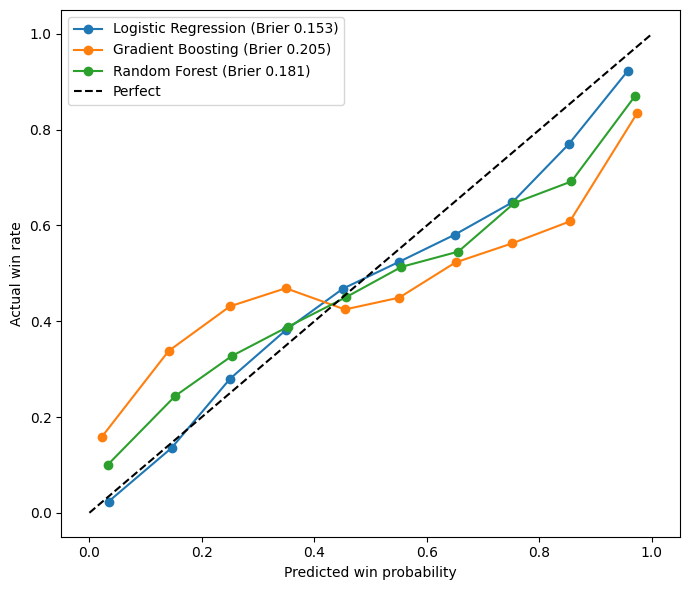

In [69]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, r in results.items():
    frac, mean_pred = calibration_curve(y_test, r["proba"], n_bins=10)
    ax.plot(mean_pred, frac, marker="o", label=f"{name} (Brier {r['Brier']:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Perfect")
ax.set_xlabel("Predicted win probability"); ax.set_ylabel("Actual win rate")
ax.legend(); plt.tight_layout(); plt.savefig("calibration_plot.png", dpi=150); plt.show()

In [70]:
sim = data[data.runs_needed.between(85,115) & data.balls_remaining.between(54,66)
           & (data.wickets_in_hand >= 8)]
print(f"{len(sim):,} historical cases | actual win rate: {sim.won.mean():.1%}\n")
for name, pipe in models.items():
    print(f"{name:22s} avg prediction: {pipe.predict_proba(sim[FEATURES])[:,1].mean():.1%}")

chin = sim[sim.venue.str.contains("Chinnaswamy")]
print(f"\nChinnaswamy: {len(chin)} cases, actual {chin.won.mean():.1%}")

3,360 historical cases | actual win rate: 60.4%

Logistic Regression    avg prediction: 65.9%
Gradient Boosting      avg prediction: 59.5%
Random Forest          avg prediction: 59.5%

Chinnaswamy: 332 cases, actual 59.9%


In [71]:
BEST = "Logistic Regression"   # <- change if your numbers say otherwise

joblib.dump({"model": models[BEST], "features": FEATURES,
             "venues": sorted(data["venue"].unique().tolist()), "name": BEST},
            "win_predictor_v2.joblib")
print("Saved win_predictor_v2.joblib")

Saved win_predictor_v2.joblib


In [72]:
%%writefile app.py
from pathlib import Path
import joblib
import pandas as pd
import streamlit as st

MODEL_PATH = Path("models/win_predictor_v2.joblib")
BALLS_PER_INNINGS = 120

st.set_page_config(page_title="IPL Win Predictor", page_icon="🏏", layout="wide")
st.title("IPL Win Predictor")

@st.cache_resource
def load_bundle():
    return joblib.load(MODEL_PATH)

bundle = load_bundle()
model, features, venues = bundle["model"], bundle["features"], bundle["venues"]

with st.sidebar:
    st.header("Match Details")
    venue = st.selectbox("Select Venue", venues)
    target = st.number_input("Target Score", 1, 300, 180)
    runs_needed = st.number_input("Runs Needed", 1, 300, 60)
    overs_left = st.number_input("Overs Remaining", 1, 20, 6)
    wickets_in_hand = st.number_input("Wickets in Hand", 1, 10, 6)

st.write("Enter the match details in the sidebar and click Predict.")

if st.button("Predict Win Probability", type="primary"):
    balls_remaining = int(overs_left * 6)
    balls_bowled = BALLS_PER_INNINGS - balls_remaining
    runs_scored = target - runs_needed

    if runs_scored < 0:
        st.error("Runs Needed cannot exceed the Target."); st.stop()
    if balls_bowled > 0 and runs_scored > balls_bowled * 6 + 10:
        st.error(f"Impossible: {runs_scored} runs cannot come from {balls_bowled} balls."); st.stop()

    current_rr = runs_scored / (balls_bowled / 6) if balls_bowled else 0.0
    required_rr = runs_needed / (balls_remaining / 6)

    X = pd.DataFrame([{
        "venue": venue, "target": target, "runs_needed": runs_needed,
        "balls_remaining": balls_remaining, "wickets_in_hand": wickets_in_hand,
        "current_run_rate": current_rr, "required_run_rate": required_rr,
        "rr_pressure": required_rr - current_rr,
    }])[features]

    win_prob = model.predict_proba(X)[0, 1]

    st.subheader("Prediction Results")
    c1, c2, c3 = st.columns(3)
    c1.metric("Win Probability (Chasing Team)", f"{win_prob:.1%}")
    c2.metric("Current Run Rate", f"{current_rr:.2f}")
    c3.metric("Required Run Rate", f"{required_rr:.2f}")
    st.progress(min(max(win_prob, 0.0), 1.0))
    st.caption(f"{runs_needed} needed off {balls_remaining} balls at {venue} "
               f"({wickets_in_hand} wickets in hand)")
    if current_rr > 15:
        st.warning("Very high current run rate — rare in training data; treat with caution.")

st.markdown("---")
st.caption(f"Model: {bundle['name']} | 1,100+ IPL matches (Cricsheet) | match-level validation.")

Overwriting app.py


In [73]:
import sklearn; print(sklearn.__version__)

1.6.1


In [74]:
sim = data[data.runs_needed.between(105,135) & data.balls_remaining.between(54,66)
           & data.wickets_in_hand.between(6,8)]
print(f"{len(sim):,} historical cases | actual win rate: {sim.won.mean():.1%}")

# era check — has modern hitting changed it?
sim = sim.copy()
sim["year"] = sim["season"].str[:4].astype(int)
print(sim.groupby(sim.year >= 2022)["won"].agg(["count", "mean"]))

# model's average on those same rows
print(f"Model avg: {models['Logistic Regression'].predict_proba(sim[FEATURES])[:,1].mean():.1%}")

2,958 historical cases | actual win rate: 22.0%
       count      mean
year                  
False   1844  0.187093
True    1114  0.273788
Model avg: 24.7%
